Seasonal Agriculture Performance Analysis

2.Project Objectives
. Explore and understand the dataset.  
. Clean and prepare the data for analysis.  
. Examine how agricultural performance varies across seasons.  
. Identify important seasonal patterns and trends.  
. Investigate relationships between seasonal conditions and agricultural outcomes.  
. Compare relevant groups within different seasons.  
. Identify significant differences or unusual patterns.  
. Apply appropriate statistical and visualization techniques.  
. Interpret findings based on evidence from the dataset.  
. Develop meaningful conclusions and data-driven recommendations. 

3.Dataset

The dataset contains farm-level agricultural records covering different seasons,locations,crops,environmental conditions,farming practices,production,costs,revenue,profit and resource usage.
Dataset:seasonal_agriculture_performance_dataset.csv
The notebook is designed so that students can upload/place the CSV in the same folder as this notebook

In [35]:
#Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
# Load Dataset
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

In [6]:
display(df.head())

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [8]:
# 3. Understand the dataset

print(df.columns.tolist())
display(df.dtypes.to_frame("Data Type"))
display(df.describe(include="all").T)


['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


In [9]:
# 4. Check data quality

display(df.isnull().sum().sort_values(ascending=False).to_frame("Missing Values"))

print("Duplicate rows:", df.duplicated().sum())

print("\nUnique values in important categorical columns:")
for col in ["State", "District", "Crop", "Season", "Irrigation_Method"]:
    print(f"{col}: {df[col].nunique()}")


,Missing Values
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Irrigation_Method,0
Water_Efficiency_t_per_1000m3,0
Water_Used_m3,0
Profit_INR,0
Revenue_INR,0
Total_Cost_INR,0


Duplicate rows: 0

Unique values in important categorical columns:
State: 8
District: 10
Crop: 8
Season: 3
Irrigation_Method: 4


In [10]:
# 5. Data cleaning

# Remove duplicate rows if any
df = df.drop_duplicates().copy()


for col in ["Rainfall_mm", "Soil_Moisture_pct"]:
    df[col] = df.groupby("Season")[col].transform(lambda x: x.fillna(x.median()))


df = df.dropna(subset=["Yield_Tonnes_Ha"]).copy()

print("Shape after cleaning:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())


Shape after cleaning: (3968, 28)
Remaining missing values: 0


In [11]:
# 6. Seasonal summary table
season_summary = df.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield_t_ha=("Yield_Tonnes_Ha", "mean"),
    Avg_Production_t=("Production_Tonnes", "mean"),
    Avg_Rainfall_mm=("Rainfall_mm", "mean"),
    Avg_Temperature_C=("Avg_Temperature_C", "mean"),
    Avg_Water_Used_m3=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Revenue_INR=("Revenue_INR", "mean"),
    Avg_Profit_INR=("Profit_INR", "mean"),
    Avg_Disease_Pest_Risk_pct=("Disease_Pest_Risk_pct", "mean")
).round(2)

display(season_summary)


,Farms,Avg_Yield_t_ha,Avg_Production_t,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Revenue_INR,Avg_Profit_INR,Avg_Disease_Pest_Risk_pct
Season,,,,,,,,,,
Kharif,1772,5.64,46.44,851.61,28.45,6094.05,5.91,711441.28,179367.12,54.47
Rabi,1607,5.08,41.34,436.23,23.50,5837.24,5.18,601825.55,88197.25,40.52
Zaid,589,4.67,39.15,298.67,31.05,6423.08,4.44,516662.12,-26592.40,38.22


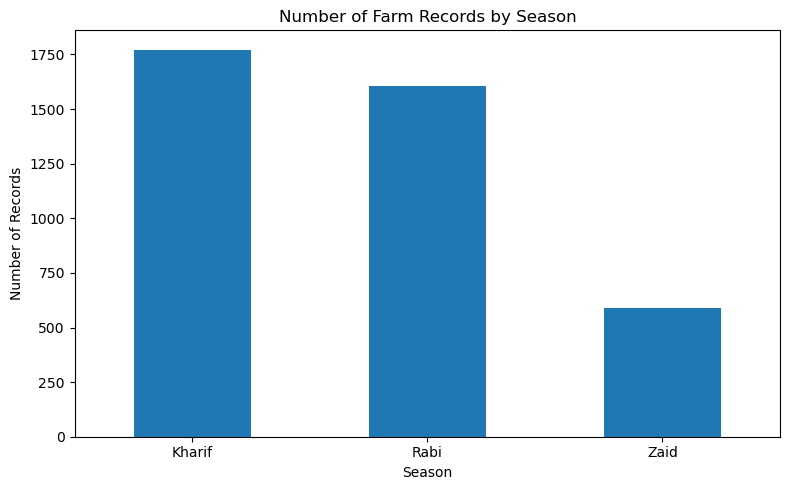

In [12]:
season_counts = df["Season"].value_counts().reindex(["Kharif", "Rabi", "Zaid"])

plt.figure(figsize=(8,5))
season_counts.plot(kind="bar")
plt.title("Number of Farm Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


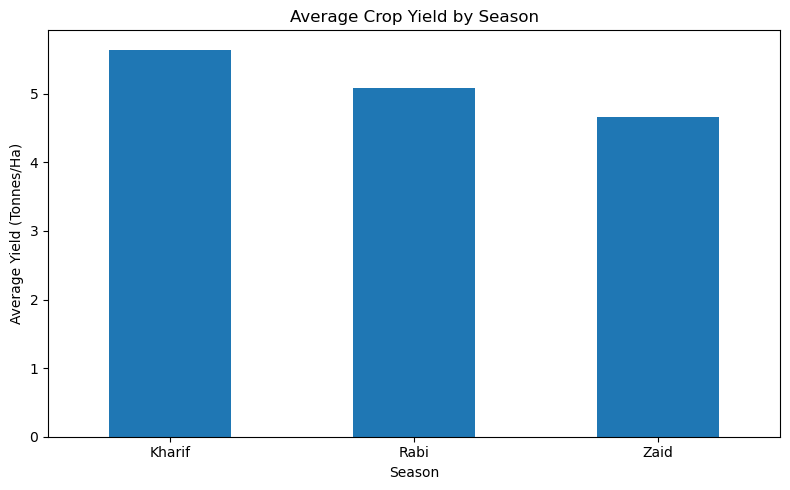

In [13]:
avg_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean().reindex(["Kharif", "Rabi", "Zaid"])

plt.figure(figsize=(8,5))
avg_yield.plot(kind="bar")
plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


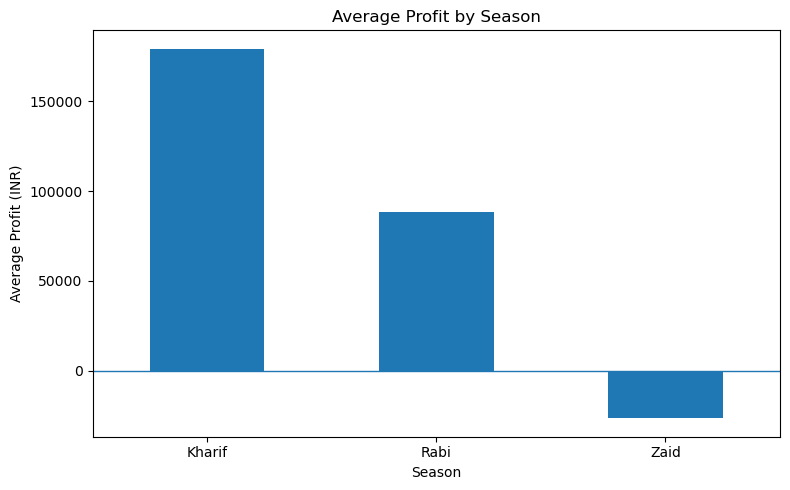

In [14]:
avg_profit = df.groupby("Season")["Profit_INR"].mean().reindex(["Kharif", "Rabi", "Zaid"])

plt.figure(figsize=(8,5))
avg_profit.plot(kind="bar")
plt.axhline(0, linewidth=1)
plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

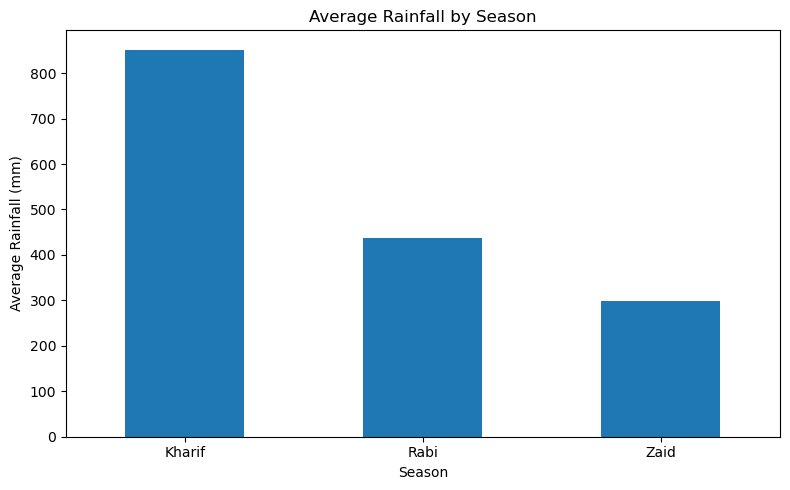

In [15]:
avg_rainfall = df.groupby("Season")["Rainfall_mm"].mean().reindex(["Kharif", "Rabi", "Zaid"])

plt.figure(figsize=(8,5))
avg_rainfall.plot(kind="bar")
plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Average Rainfall (mm)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


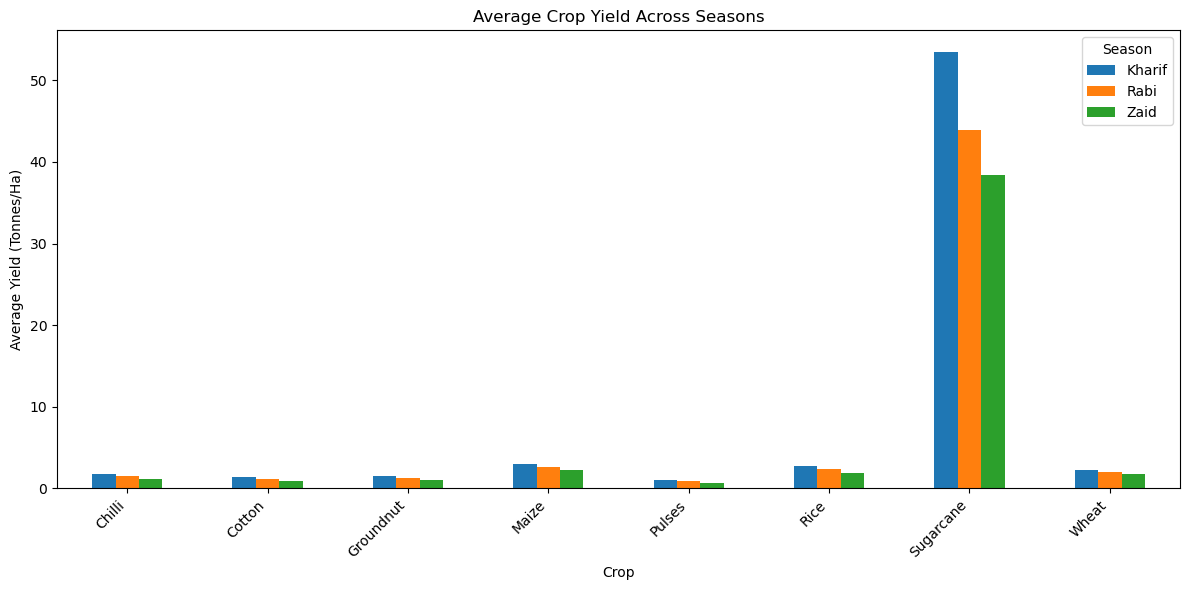

In [16]:
crop_season_yield = df.pivot_table(
    index="Crop",
    columns="Season",
    values="Yield_Tonnes_Ha",
    aggfunc="mean"
)

crop_season_yield = crop_season_yield[["Kharif", "Rabi", "Zaid"]]

crop_season_yield.plot(kind="bar", figsize=(12,6))
plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Season")
plt.tight_layout()
plt.show()


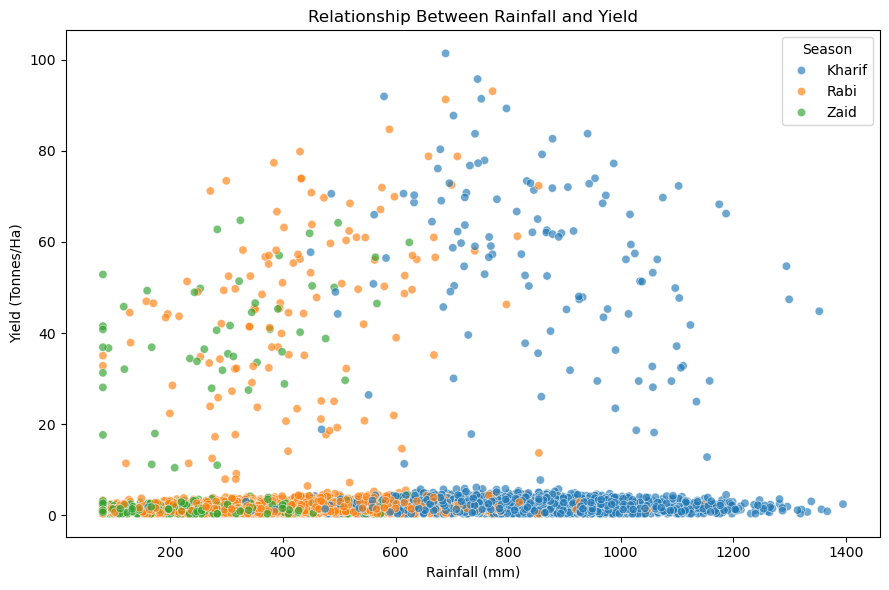

In [17]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.65
)
plt.title("Relationship Between Rainfall and Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()


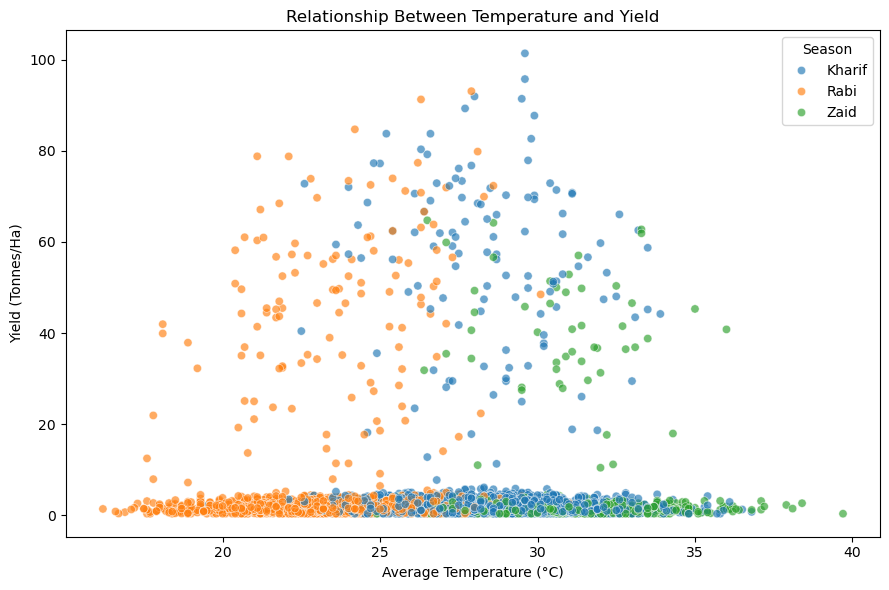

In [18]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df,
    x="Avg_Temperature_C",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.65
)
plt.title("Relationship Between Temperature and Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()


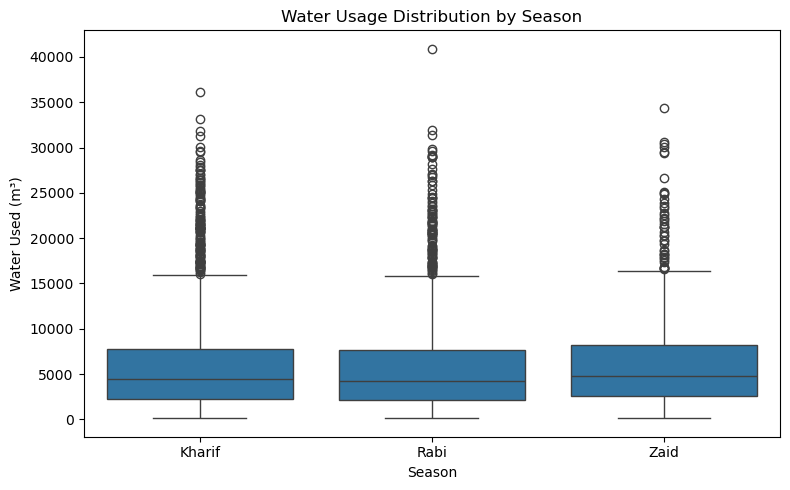

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Season", y="Water_Used_m3", order=["Kharif", "Rabi", "Zaid"])
plt.title("Water Usage Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.tight_layout()
plt.show()


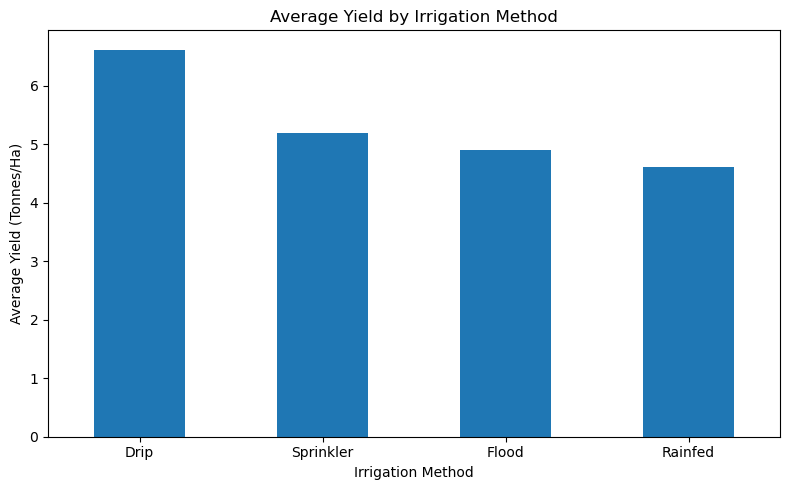

In [20]:
irrigation_yield = df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
irrigation_yield.plot(kind="bar")
plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


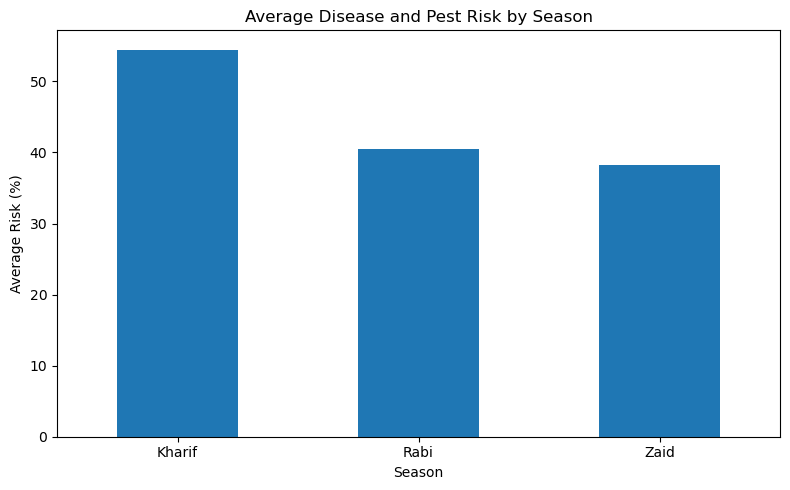

In [21]:
risk = df.groupby("Season")["Disease_Pest_Risk_pct"].mean().reindex(["Kharif", "Rabi", "Zaid"])

plt.figure(figsize=(8,5))
risk.plot(kind="bar")
plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Average Risk (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


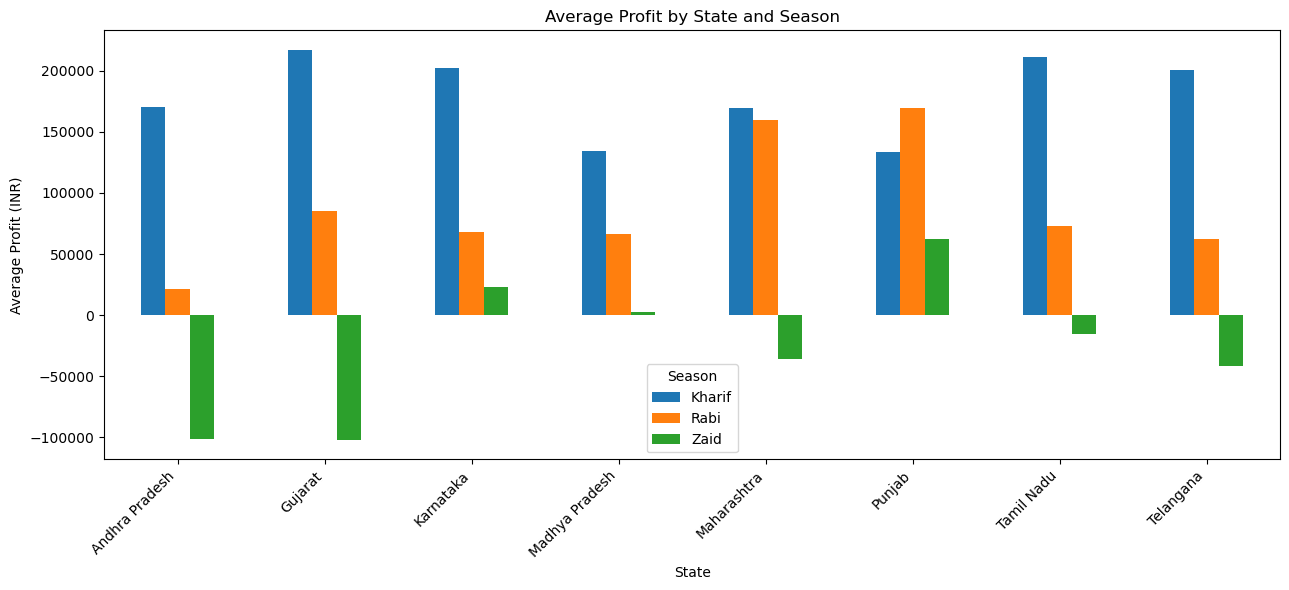

In [22]:
state_season_profit = df.pivot_table(
    index="State",
    columns="Season",
    values="Profit_INR",
    aggfunc="mean"
)[["Kharif", "Rabi", "Zaid"]]

state_season_profit.plot(kind="bar", figsize=(13,6))
plt.title("Average Profit by State and Season")
plt.xlabel("State")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Season")
plt.tight_layout()
plt.show()


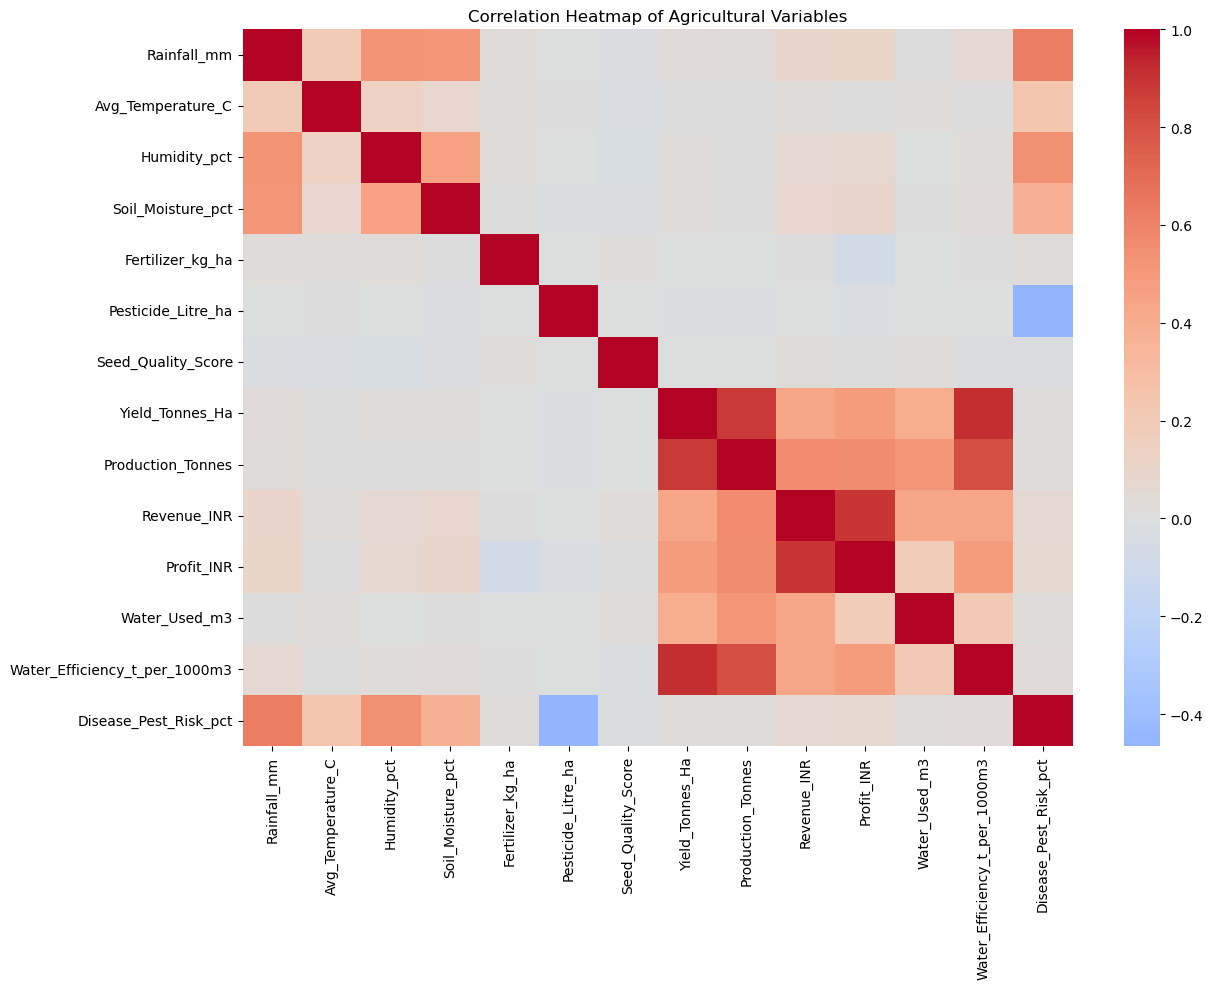

In [23]:
numeric_cols = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Soil_Moisture_pct", "Fertilizer_kg_ha",
    "Pesticide_Litre_ha", "Seed_Quality_Score",
    "Yield_Tonnes_Ha", "Production_Tonnes",
    "Revenue_INR", "Profit_INR", "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(13,10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap of Agricultural Variables")
plt.tight_layout()
plt.show()


In [24]:
best_crop_by_season = (
    df.groupby(["Season", "Crop"])["Yield_Tonnes_Ha"]
      .mean()
      .reset_index()
      .sort_values(["Season", "Yield_Tonnes_Ha"], ascending=[True, False])
      .groupby("Season")
      .head(1)
)

display(best_crop_by_season)


,Season,Crop,Yield_Tonnes_Ha
6,Kharif,Sugarcane,53.459120
14,Rabi,Sugarcane,43.940394
22,Zaid,Sugarcane,38.423922


In [25]:
best_state_profit = (
    df.groupby(["Season", "State"])["Profit_INR"]
      .mean()
      .reset_index()
      .sort_values(["Season", "Profit_INR"], ascending=[True, False])
      .groupby("Season")
      .head(1)
)

display(best_state_profit)


,Season,State,Profit_INR
1,Kharif,Gujarat,217051.330317
13,Rabi,Punjab,169294.521505
21,Zaid,Punjab,62109.688312


In [26]:
# Automatically print key seasonal findings
summary = df.groupby("Season").agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Rainfall=("Rainfall_mm", "mean"),
    Avg_Water_Use=("Water_Used_m3", "mean"),
    Avg_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)

print("Seasonal Performance Summary")
display(summary)

print("Highest average yield season:", summary["Avg_Yield"].idxmax())
print("Highest average profit season:", summary["Avg_Profit"].idxmax())
print("Highest average rainfall season:", summary["Avg_Rainfall"].idxmax())
print("Highest average water-use season:", summary["Avg_Water_Use"].idxmax())
print("Highest disease/pest-risk season:", summary["Avg_Risk"].idxmax())


Seasonal Performance Summary


,Avg_Yield,Avg_Profit,Avg_Rainfall,Avg_Water_Use,Avg_Risk
Season,,,,,
Kharif,5.64,179367.12,851.61,6094.05,54.47
Rabi,5.08,88197.25,436.23,5837.24,40.52
Zaid,4.67,-26592.40,298.67,6423.08,38.22


Highest average yield season: Kharif
Highest average profit season: Kharif
Highest average rainfall season: Kharif
Highest average water-use season: Zaid
Highest disease/pest-risk season: Kharif


In [27]:

# Identify unusual yield values using IQR

Q1 = df["Yield_Tonnes_Ha"].quantile(0.25)
Q3 = df["Yield_Tonnes_Ha"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

unusual_yield = df[
    (df["Yield_Tonnes_Ha"] < lower_limit) |
    (df["Yield_Tonnes_Ha"] > upper_limit)
]

print("Number of unusual yield observations:", len(unusual_yield))

display(
    unusual_yield[
        ["State", "District", "Crop", "Season",
         "Yield_Tonnes_Ha", "Profit_INR"]
    ].head(10)
)

Number of unusual yield observations: 302


,State,District,Crop,Season,Yield_Tonnes_Ha,Profit_INR
47,Punjab,Ludhiana,Sugarcane,Zaid,36.69,556688
75,Maharashtra,Guntur,Sugarcane,Kharif,62.58,1675730
79,Karnataka,Nashik,Sugarcane,Zaid,33.55,691166
82,Andhra Pradesh,Raichur,Sugarcane,Rabi,49.52,279221
92,Gujarat,Guntur,Sugarcane,Kharif,70.23,2427692
113,Tamil Nadu,Rajkot,Sugarcane,Rabi,58.06,2324331
132,Telangana,Warangal,Sugarcane,Kharif,29.47,89113
154,Telangana,Ludhiana,Sugarcane,Kharif,47.88,798280
155,Madhya Pradesh,Guntur,Sugarcane,Kharif,62.09,573019
164,Telangana,Guntur,Sugarcane,Rabi,36.91,297233


In [28]:
season_performance = df.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Production=("Production_Tonnes", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)

display(season_performance)

,Average_Yield,Average_Production,Average_Revenue,Average_Profit,Average_Water_Used,Average_Risk
Season,,,,,,
Kharif,5.64,46.44,711441.28,179367.12,6094.05,54.47
Rabi,5.08,41.34,601825.55,88197.25,5837.24,40.52
Zaid,4.67,39.15,516662.12,-26592.40,6423.08,38.22


In [29]:
print("Highest Yield Season:",
      season_performance["Average_Yield"].idxmax())

print("Highest Profit Season:",
      season_performance["Average_Profit"].idxmax())

print("Highest Water Usage Season:",
      season_performance["Average_Water_Used"].idxmax())

print("Highest Disease/Pest Risk Season:",
      season_performance["Average_Risk"].idxmax())

Highest Yield Season: Kharif
Highest Profit Season: Kharif
Highest Water Usage Season: Zaid
Highest Disease/Pest Risk Season: Kharif


In [30]:
# Correlation between environmental conditions and yield

environmental_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Soil_Moisture_pct"
]

environment_yield_corr = df[
    environmental_columns + ["Yield_Tonnes_Ha"]
].corr()["Yield_Tonnes_Ha"].sort_values(ascending=False)

display(environment_yield_corr)

Yield_Tonnes_Ha      1.000000
Rainfall_mm          0.028344
Humidity_pct         0.011277
Soil_Moisture_pct    0.010160
Avg_Temperature_C    0.009349
Name: Yield_Tonnes_Ha, dtype: float64

In [31]:
# Compare average profit across states and seasons

regional_analysis = df.groupby(
    ["State", "Season"]
)["Profit_INR"].mean().unstack()

display(regional_analysis.round(2))

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169961.92,21744.00,-101513.60
Gujarat,217051.33,85405.18,-101865.86
Karnataka,202571.40,67875.11,23310.91
Madhya Pradesh,134187.49,66592.76,2539.63
Maharashtra,169867.55,159581.50,-35544.90
Punjab,133779.10,169294.52,62109.69
Tamil Nadu,211303.96,72767.13,-15175.20
Telangana,200398.64,62451.89,-41385.90


In [32]:
crop_season = df.groupby(
    ["Season", "Crop"]
)["Yield_Tonnes_Ha"].mean().reset_index()

best_crop = (
    crop_season
    .sort_values(
        ["Season", "Yield_Tonnes_Ha"],
        ascending=[True, False]
    )
    .groupby("Season")
    .head(1)
)

display(best_crop)

,Season,Crop,Yield_Tonnes_Ha
6,Kharif,Sugarcane,53.459120
14,Rabi,Sugarcane,43.940394
22,Zaid,Sugarcane,38.423922


In [33]:
print("CONCLUSION")
print("-" * 50)

highest_yield = season_performance["Average_Yield"].idxmax()
highest_profit = season_performance["Average_Profit"].idxmax()

print(f"{highest_yield} has the highest average agricultural yield.")
print(f"{highest_profit} has the highest average profit.")

print(
    "The analysis shows that agricultural performance, "
    "resource usage, environmental conditions and economic "
    "outcomes vary across seasons."
)

CONCLUSION
--------------------------------------------------
Kharif has the highest average agricultural yield.
Kharif has the highest average profit.
The analysis shows that agricultural performance, resource usage, environmental conditions and economic outcomes vary across seasons.


In [34]:
print("RECOMMENDATIONS")
print("-" * 50)

print("1. Select suitable crops according to seasonal conditions.")
print("2. Plan irrigation based on seasonal water requirements.")
print("3. Monitor disease and pest risk during high-risk seasons.")
print("4. Focus on farming practices that improve yield and profitability.")
print("5. Use regional and seasonal performance data for better planning.")
print("6. Investigate unusual yield and profit observations before making decisions.")

RECOMMENDATIONS
--------------------------------------------------
1. Select suitable crops according to seasonal conditions.
2. Plan irrigation based on seasonal water requirements.
3. Monitor disease and pest risk during high-risk seasons.
4. Focus on farming practices that improve yield and profitability.
5. Use regional and seasonal performance data for better planning.
6. Investigate unusual yield and profit observations before making decisions.
